# Session 2 Exercise: Multilayer Perceptrons & Activation Functions

**Introduction to Machine Learning — Session 2: Parametric Classifiers II**

In this notebook you will:

1. See the single-layer perceptron fail on a non-linearly-separable dataset
2. Implement a small **multilayer perceptron (MLP)** from scratch, including backpropagation
3. Train it with gradient descent and watch the loss decrease
4. Visualise the (now curved) decision boundary
5. Evaluate your NN on the test dataset
6. Stretch task: compare sigmoid, tanh, and ReLU activation functions

Cells marked **`# TODO`** are for you to complete.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
plt.close('all')
%matplotlib inline

## 1. A dataset the perceptron can't solve

We'll build an XOR-style dataset: four clusters arranged so that opposite corners share a
class. No straight line can separate these two classes — this is exactly the kind of problem
that motivated session 2.

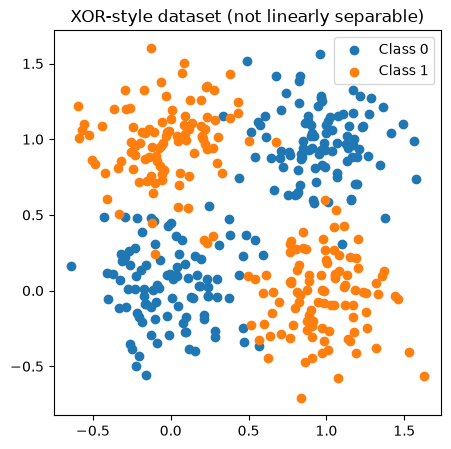

In [2]:
def make_xor_dataset(n_per_cluster=100, noise=0.25):
    centers = [(0, 0), (1, 1), (0, 1), (1, 0)]
    labels = [0, 0, 1, 1]
    X, y = [], []
    for (cx, cy), label in zip(centers, labels):
        pts = np.random.randn(n_per_cluster, 2) * noise + np.array([cx, cy])
        X.append(pts)
        y.append(np.full(n_per_cluster, label))
    X = np.vstack(X)
    y = np.hstack(y)
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

X, y = make_xor_dataset()

plt.figure(figsize=(5, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")
plt.title("XOR-style dataset (not linearly separable)")
plt.legend(); plt.show()

### Separate the dataset into train, validate, test

**`# TODO`**: Copy the code from previous session

In [3]:
# TODO - split the dataset into train, validation and test - create variables X_train, y_train, X_val, y_val, X_test, y_test
def split_data(X, y, train_frac=0.6, val_frac=0.2):
    """Split X, y into train/val/test sets according to the given fractions."""
    n = len(X)
    idx = np.random.permutation(n)

    #--------------
    # TODO: compute the number of training and validation examples
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    #--------------

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    return (X[train_idx], y[train_idx],
            X[val_idx], y[val_idx],
            X[test_idx], y[test_idx])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

print("Train size:", len(X_train))
print("Val size:  ", len(X_val))
print("Test size: ", len(X_test))

Train size: 240
Val size:   80
Test size:  80


### Run the dataset through the perceptron from last session

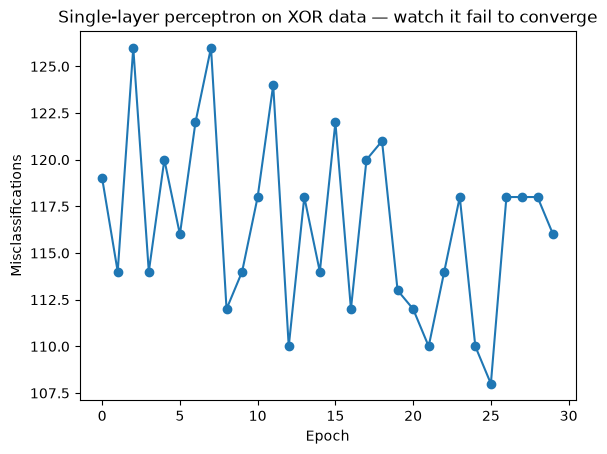

In [4]:
# Reminder: last session's perceptron, unmodified
class Perceptron:
    def __init__(self, n_features, learning_rate=0.1):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = learning_rate

    def predict(self, X):
        return (X @ self.w + self.b >= 0).astype(int)

    def fit(self, X, y, epochs=20):
        errors_history = []
        for _ in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_hat = self.predict(xi.reshape(1, -1))[0]
                update = self.lr * (yi - y_hat)
                self.w += update * xi
                self.b += update
                errors += int(update != 0)
            errors_history.append(errors)
        return errors_history

p = Perceptron(n_features=2)
history = p.fit(X_train, y_train, epochs=30)
plt.plot(history, marker="o")
plt.xlabel("Epoch"); plt.ylabel("Misclassifications")
plt.title("Single-layer perceptron on XOR data — watch it fail to converge")
plt.show()

## 2. Build a multilayer perceptron

We'll use one hidden layer with a sigmoid activation, and a sigmoid output for binary
classification, trained with **backpropagation** and **gradient descent**.

Architecture: `2 inputs -> hidden_size hidden units -> 1 output`

Forward pass:
$$z_1 = X W_1 + b_1, \quad a_1 = \sigma(z_1)$$
$$z_2 = a_1 W_2 + b_2, \quad a_2 = \sigma(z_2) = \hat{y}$$

Loss (binary cross-entropy):
$$L = -\frac{1}{n}\sum \big[y \log(\hat y) + (1-y)\log(1-\hat y)\big]$$

**`# TODO`**: complete the forward pass and the backward pass (gradients).

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):
    # derivative of sigmoid, expressed in terms of the *activation* a = sigmoid(z)
    return a * (1 - a)

class MLP:
    def __init__(self, n_inputs, hidden_size, lr=0.5, seed=1):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_inputs, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = rng.randn(hidden_size, 1) * 0.5
        self.b2 = np.zeros((1, 1))
        self.lr = lr

    def forward(self, X):
        #--------------
        # TODO: compute z1, a1, z2, a2 following the equations above
        z1 = X @ self.W1 + self.b1
        a1 = sigmoid(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)
        #--------------
        cache = (X, z1, a1, z2, a2)
        return a2, cache

    def backward(self, cache, y):
        X, z1, a1, z2, a2 = cache
        n = X.shape[0]
        y = y.reshape(-1, 1) #changing from vector to array

        # Output layer gradient (cross-entropy + sigmoid combine nicely):
        dz2 = a2 - y                      # (n, 1)
        dW2 = a1.T @ dz2 / n
        db2 = np.sum(dz2, axis=0, keepdims=True) / n

        #--------------
        # TODO: backpropagate into the hidden layer
        da1 = dz2 @ self.W2.T                # (n, hidden_size)
        dz1 = da1 * sigmoid_deriv(a1)          # (n, hidden_size)
        dW1 = X.T @ dz1 / n
        db1 = np.sum(dz1, axis=0, keepdims=True) / n
        #--------------

        return dW1, db1, dW2, db2

    def step(self, dW1, db1, dW2, db2):
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y, X_val=None, y_val=None, epochs=2000):
        losses, val_losses = [], []
        for _ in range(epochs):
            a2, cache = self.forward(X)
            eps = 1e-9
            loss = -np.mean(y * np.log(a2[:, 0] + eps) + (1 - y) * np.log(1 - a2[:, 0] + eps))
            losses.append(loss)

            if X_val is not None:
                a2_val, _ = self.forward(X_val)
                val_loss = -np.mean(y_val * np.log(a2_val[:, 0] + eps) + (1 - y_val) * np.log(1 - a2_val[:, 0] + eps))
                val_losses.append(val_loss)

            grads = self.backward(cache, y)
            self.step(*grads)
        return losses, val_losses

    def predict(self, X):
        a2, _ = self.forward(X)
        return (a2.ravel() >= 0.5).astype(int)

## 3. Train the MLP and check the loss curve

If your forward/backward pass are correct, the loss should decrease steadily toward a low
value (it won't necessarily hit exactly zero — that's fine).

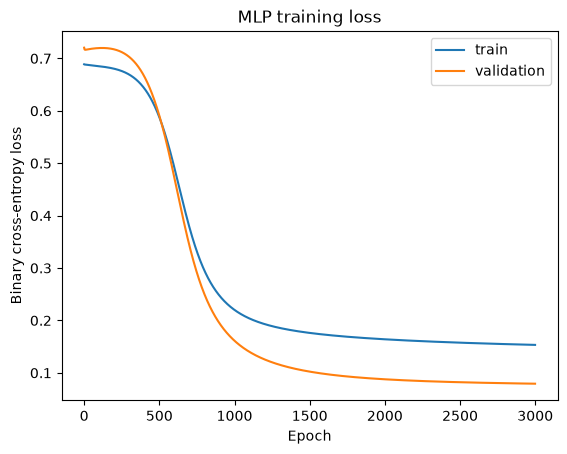

Training accuracy:   0.938
Validation accuracy: 0.975


In [8]:
mlp = MLP(n_inputs=2, hidden_size=8, lr=0.5)
losses, val_losses = mlp.train(X_train, y_train, X_val, y_val, epochs=3000)

plt.plot(losses, label="train")
plt.plot(val_losses, label="validation")
plt.xlabel("Epoch"); plt.ylabel("Binary cross-entropy loss")
plt.title("MLP training loss")
plt.legend()
plt.show()

train_preds = mlp.predict(X_train)
val_preds = mlp.predict(X_val)
print(f"Training accuracy:   {np.mean(train_preds == y_train):.3f}")
print(f"Validation accuracy: {np.mean(val_preds == y_val):.3f}")

## 4. Visualise the (curved) decision boundary

Unlike the perceptron's straight line, the MLP should be able to carve out a
non-linear region that correctly separates the XOR pattern. We plot the
**test set** here rather than the training data — the interesting question
isn't just "did it fit what it saw," but "does the boundary it learned still
make sense on points it never trained on."

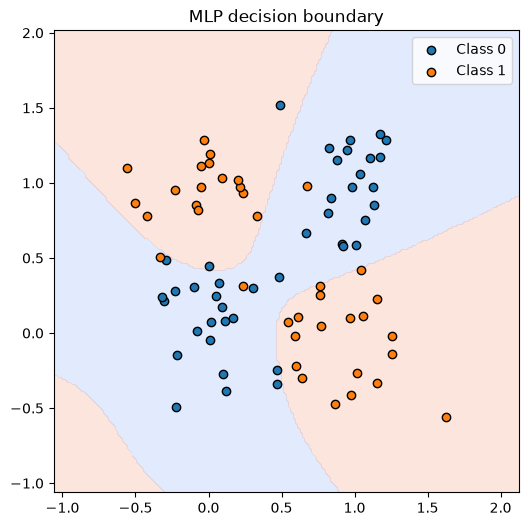

In [9]:
def plot_mlp_boundary(model, X, y, resolution=200):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                          np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, preds, alpha=0.25, levels=1, cmap="coolwarm")
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", edgecolor="k")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", edgecolor="k")
    plt.title("MLP decision boundary")
    plt.legend(); plt.show()

plot_mlp_boundary(mlp, X_test, y_test)

## 5. Evaluate your NN on test dataset
Now — and only now — we touch the test set for scoring. Build the confusion
matrix, precision, and recall exactly as in Session 1, reusing the same
definitions:

- **True Positive (TP)**: predicted 1, actually 1
- **False Positive (FP)**: predicted 1, actually 0
- **True Negative (TN)**: predicted 0, actually 0
- **False Negative (FN)**: predicted 0, actually 1

**`# TODO`**: calculate `confusion_counts`, then `precision` and `recall`
Use the code from the previous session!

In [15]:
def confusion_counts(y_true, y_pred):
    #------------------
    # TODO: compute TP, FP, TN, FN using boolean masks
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    #------------------

    return tp, fp, tn, fn

y_val_pred = mlp.predict(X_val)
tp, fp, tn, fn = confusion_counts(y_val, y_val_pred)

print(f"TP={tp}  FP={fp}")
print(f"FN={fn}  TN={tn}")

confusion_matrix = np.array([[tn, fp],
                              [fn, tp]])
print("\nConfusion matrix [rows=actual, cols=predicted], order=[0,1]:")
print(confusion_matrix)

def precision(tp, fp):
    #------------------
    # TODO: return tp / (tp + fp), guarding against division by zero
    return tp / (tp + fp)
    #------------------

def recall(tp, fn):
    #------------------
    # TODO: return tp / (tp + fn), guarding against division by zero
    return tp / (tp + fn)
    #------------------

prec = precision(tp, fp)
rec = recall(tp, fn)
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

TP=35  FP=2
FN=0  TN=43

Confusion matrix [rows=actual, cols=predicted], order=[0,1]:
[[43  2]
 [ 0 35]]
Precision: 0.946
Recall:    1.000


## 6. Stretch task: compare activation functions

Below is a lightweight variant of the MLP that lets you swap in a different hidden-layer
activation. Try `"sigmoid"`, `"tanh"`, and `"relu"` and compare the resulting loss curves.

**`# TODO`**: implement the `tanh` and `relu` branches (forward activation + derivative).

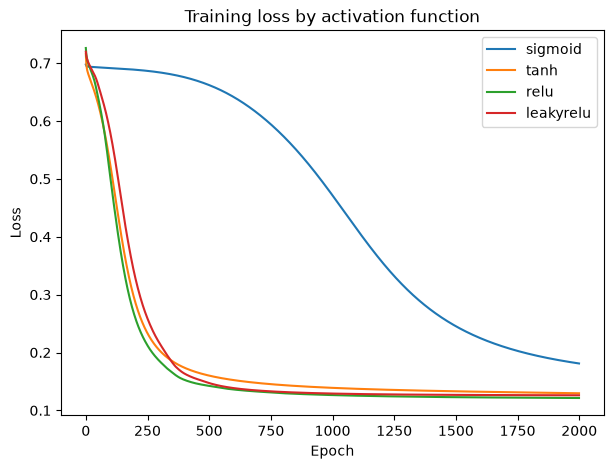

In [19]:
def activation(z, kind):
    if kind == "sigmoid":
        a = 1 / (1 + np.exp(-z))
    elif kind == "tanh":
        #--------------
        # TODO: a = np.tanh(z)
        a = np.tanh(z)
        #--------------
    elif kind == "relu":
        #--------------
        # TODO: a = np.maximum(0, z)
        a = np.maximum(0, z)
        #--------------
    elif kind == 'leakyrelu':
        #--------------
        # TODO: a = 0.9*np.maximum(0, z) + 0.1*z
        a = 0.9*np.maximum(0, z) + 0.1*z
        #--------------
    else:
        raise ValueError(kind)
    return a

def activation_deriv(a, kind):
    if kind == "sigmoid":
        d = a * (1 - a)
    elif kind == "tanh":
        #--------------
        # TODO: derivative of tanh in terms of a: 1 - a**2
        d = 1 - a**2
        #--------------
    elif kind == "relu":
        #--------------
        # TODO: derivative of relu in terms of a: 1 where a > 0, else 0
        d = np.where(a > 0, 1, 0)
        #--------------
    elif kind == 'leakyrelu':
        #--------------
        # TODO: derivative of leakyrelu in terms of a: 0.9 where a > 0, else 0.1
        d = np.where(a > 0, 0.9, 0.1)
        #--------------
    else:
        raise ValueError(kind)
    return d

class FlexibleMLP(MLP):
    def __init__(self, n_inputs, hidden_size, lr=0.5, seed=1, activation_kind="sigmoid"):
        super().__init__(n_inputs, hidden_size, lr, seed)
        self.kind = activation_kind

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = activation(z1, self.kind)
        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)  # keep output layer sigmoid for binary classification
        return a2, (X, z1, a1, z2, a2)

    def backward(self, cache, y):
        X, z1, a1, z2, a2 = cache
        n = X.shape[0]
        y = y.reshape(-1, 1)
        dz2 = a2 - y
        dW2 = a1.T @ dz2 / n
        db2 = np.sum(dz2, axis=0, keepdims=True) / n
        da1 = dz2 @ self.W2.T
        dz1 = da1 * activation_deriv(a1, self.kind)
        dW1 = X.T @ dz1 / n
        db1 = np.sum(dz1, axis=0, keepdims=True) / n
        return dW1, db1, dW2, db2

plt.figure(figsize=(7, 5))
for kind in ["sigmoid", "tanh", "relu", "leakyrelu"]:
    m = FlexibleMLP(2, 8, lr=0.3, seed=1, activation_kind=kind)
    losses_k = m.train(X, y, epochs=2000)
    plt.plot(losses_k[0], label=kind)

plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training loss by activation function")
plt.legend(); plt.show()

## Wrap-up questions

1. Why couldn't the single-layer perceptron solve the XOR dataset, no matter how long it trained?
2. What role does the activation function play — what would happen if you removed it entirely
   (i.e. made the hidden layer purely linear)?
3. In the stretch task, which activation converged fastest? Did any behave unusually?
4. Your train and validation loss curves should have tracked closely together. Would you expect
   that to still be true with a much smaller training set, or a much larger hidden layer? (No need
   to test it now — just predict.)
5. Compare test accuracy (Section 5) to the training/validation accuracy printed in Section 3.
   Are they close? What would it mean if test accuracy were noticeably lower than the other two?
